<h1 align="center" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">
<font color="#FF6A13">
Transformers in JAX &mdash; Part 3: Multi-Head Attention and the Transformer Block at Tapsi
</font>
</h1>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">
<font color="#FF6A13">
Part 1 &mdash; The Backstory
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
Two notebooks in, Nika has earned a quiet confidence on the machine-learning platform team at <b>Tapsi</b>, and the open-plan office in Vanak has started to feel like home rather than a test. In the previous milestone she built a single self-attention head by hand and watched it learn to glance backward at the right characters, and the demo drew a small crowd around her monitor. Her manager, Borna, was pleased but pointed at the whiteboard and reminded her that one head learns exactly one kind of relationship, which is far too little for a model that must one day finish a passenger's sentence. He wants several heads working in parallel, a committee of specialists where one head tracks the previous word, another tracks matching brackets, and a third watches the start of the line. He also wants the code to stop being a pile of loose functions and become real, reusable modules that the rest of the team can trust. Tonight Nika adopts <b>Flax</b>, assembles multi-head attention into a clean module, and wraps it into the full transformer block, and this is where you join her again.
</font>
</p>

<div style="text-align:center;">
    <img src="images/Tapsi_new_logo.png" style="width:100%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">
<font color="#FF6A13">
Part 2 &mdash; The Mission Brief
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
Borna lays out the plan for the evening in his usual unhurried way. The first idea is that a single attention head learns only one relationship at a time, so the team will split the model width into several smaller heads, let each one run attention independently, then concatenate the results and project them back, which is precisely the <b>multi-head attention</b> from the original paper. The second idea is that loose functions do not scale across a team, so Nika will adopt <b>Flax</b> and express every component as an <code>nn.Module</code> with the standard initialize-then-apply flow and an explicit tree of parameters. The third idea is that attention alone is not a network, so she will add a position-wise <b>MLP</b> with a <b>GELU</b> nonlinearity that gives each token room to think on its own. The fourth idea is stability, which means folding in <b>LayerNorm</b> and <b>residual connections</b> in the modern <b>pre-norm</b> arrangement so that gradients flow cleanly through a deep stack. By the end of the notebook these pieces will click together into one reusable transformer block, the single unit that the next notebook stacks into the full model. This is the third link in a continuous five-part chain where each part builds directly on the one before it, so the tokenizer from Part 1 at Snapp and the self-attention from Part 2 at Digikala feed straight into the block built here, which Part 4 stacks into a fully trained MiniGPT. Borna reminds her that everything must stay deterministic on the laptop so the automated judge can check her work to the last decimal.
</font>
</p>

<div style="text-align:center;">
    <img src="images/tapsi.jpg" style="width:100%;">
</div>

<div style="text-align:center;">
    <img src="images/multihead_attention.png" width="430">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>Multi-head attention: split into heads, run attention per head, concat, project. (Wikimedia, CC BY-SA 4.0)</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; Flax nn.Module in five minutes (init/apply, parameter pytrees)</h4>
<p style="line-height:180%; font-size:medium;">
<b>Flax</b> is a neural-network library built on JAX, and its core abstraction is the <code>nn.Module</code>. Because JAX functions must stay <b>pure</b>, a Flax module does not hide its weights inside the object the way PyTorch does; instead the parameters live in an external <b>pytree</b> (a nested dictionary of arrays) that you pass in explicitly. The workflow has exactly two steps. First you call <code>module.init(rng, sample_input)</code>, which runs the module once to discover the shapes of every weight and returns a frozen dictionary like <code>{'params': {...}}</code>. Then you call <code>module.apply(params, input)</code>, which runs the forward pass using those parameters. Inside the module you declare hyperparameters as dataclass fields (for example <code>n_head: int</code>) and you write the forward pass in a method decorated with <code>@nn.compact</code>, creating sub-layers such as <code>nn.Dense</code> inline. Because <code>init</code> is driven by an explicit PRNG key, two inits with the same key on CPU produce <b>identical</b> weights, which is exactly what makes this notebook reproducible.
</p>
<div style="text-align:center;">
    <img src="images/jax_logo.png" style="width:30%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; Multi-head attention</h4>
<p style="line-height:180%; font-size:medium;">
A single attention head computes one set of queries, keys, and values and therefore can express only one notion of relevance. <b>Multi-head attention</b> runs several heads in parallel on the same input so the model can attend to different relationships at once. Concretely, the embedding dimension <code>C</code> is split into <code>n_head</code> heads each of size <code>d_head = C / n_head</code>. One shared linear layer produces all the queries, keys, and values at once (a projection to <code>3C</code> that we split into Q, K, V), we reshape so the head axis comes before the time axis, run causal scaled-dot-product attention <b>independently</b> per head, then concatenate the per-head outputs back to width <code>C</code> and pass them through a final output projection. The cost is the same as one wide head, but the model gains several specialised views of the sequence, which is why every modern Transformer uses many heads.
</p>
<div style="text-align:center;">
    <img src="images/transformer_full_architecture.png" width="700">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>The full Transformer block: multi-head attention and a position-wise MLP, each wrapped in LayerNorm and a residual connection.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; GELU and the position-wise MLP</h4>
<p style="line-height:180%; font-size:medium;">
Attention moves information <i>between</i> positions, but a Transformer block also needs computation <i>within</i> each position, and that is the job of the position-wise <b>MLP</b> (also called the feed-forward network). It is applied to every token independently and identically: a <code>Dense</code> layer that expands the width by a factor of four, a nonlinearity, and a second <code>Dense</code> layer that projects back to the model width. The nonlinearity is <b>GELU</b>, the Gaussian Error Linear Unit, defined as <code>x &middot; &Phi;(x)</code> where <code>&Phi;</code> is the standard normal cumulative distribution. Unlike ReLU, which hard-clips every negative value to zero, GELU is smooth and lets a small, gradually vanishing amount of negative signal through, which tends to train better in Transformers. The four-times expansion gives each token a roomy hidden space to recombine the features that attention just gathered.
</p>
<div style="text-align:center;">
    <img src="images/tapsi2.jpg" style="width:100%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; LayerNorm</h4>
<p style="line-height:180%; font-size:medium;">
<b>Layer normalization</b> stabilises training by standardising the activations of each token <i>across its feature dimension</i>. For a single token vector it subtracts the mean and divides by the standard deviation computed over the <code>C</code> features, so the normalised vector has zero mean and unit variance regardless of the scale produced by the previous layer. It then rescales and shifts the result with two learned vectors, <code>&gamma;</code> (scale) and <code>&beta;</code> (shift), so the network can recover any distribution it actually needs. Unlike batch normalization, LayerNorm does not mix information across the batch or across time, which makes it a natural fit for autoregressive language models where each position must be processed without peeking at its neighbours. You will implement the normalisation by hand and confirm it matches Flax's <code>nn.LayerNorm</code> exactly.
</p>
<div style="text-align:center;">
    <img src="images/tapsi3.jpg" style="width:100%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; Residual connections and pre-norm</h4>
<p style="line-height:180%; font-size:medium;">
A deep stack of layers is hard to train because gradients have to survive a long multiplicative path. <b>Residual connections</b> fix this by adding each sub-layer's output back to its input, <code>x &rarr; x + f(x)</code>, so there is always a clean additive highway through which gradients flow unchanged. The remaining question is <i>where</i> to put the LayerNorm. The original Transformer used <b>post-norm</b>, normalising after the residual add, but modern GPT-style models use <b>pre-norm</b>, normalising the input <i>before</i> each sub-layer and leaving the residual path itself untouched. The block you build is pre-norm and reads as <code>x = x + Attention(LayerNorm(x))</code> followed by <code>x = x + MLP(LayerNorm(x))</code>. Pre-norm is the configuration that lets people train very deep Transformers reliably, and it is the layout this lab uses everywhere.
</p>
<div style="text-align:center;">
    <img src="images/tapsi4.png" style="width:100%;">
</div>

In [1]:
import os, time, math, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

print("JAX", jax.__version__, "| Flax", nn.__version__ if hasattr(nn,"__version__") else "", "| devices:", jax.devices())

JAX 0.10.2 | Flax  | devices: [CpuDevice(id=0)]


<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; Continuing from Part 2</h4>
<p style="line-height:180%; font-size:medium;">
The setup cell below carries Parts 1 and 2 forward <b>unchanged</b>. The character tokenizer comes from Part 1 at Snapp, and the <code>scaled_dot_product_attention</code> helper is exactly the causal, scaled, softmax-weighted attention that you built by hand in Part 2 at Digikala, reused here verbatim with no edits. Nothing in this recap is new; it is the shared foundation. What you build on top of it in this notebook, the multi-head attention module and the full pre-norm transformer block, is the single reusable unit that Part 4 stacks into the trained MiniGPT, so every line you complete tonight reappears in the final model.
</p>

In [2]:
# Setup (given) — solved code from Parts 1-2.

def load_tiny_shakespeare():
    for path in ("data/tiny_shakespeare.txt", "tiny_shakespeare.txt", "../data/tiny_shakespeare.txt"):
        if os.path.exists(path):
            return open(path, encoding="utf-8").read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(url, "data/tiny_shakespeare.txt")
    return open("data/tiny_shakespeare.txt", encoding="utf-8").read()

text = load_tiny_shakespeare()
print(f"Corpus length: {len(text):,} characters")

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

data = np.array(encode(text), dtype=np.int32)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")

def get_batch(key, split, batch_size, block_size):
    source = train_data if split == "train" else val_data
    ix = jax.random.randint(key, (batch_size,), 0, len(source) - block_size - 1)
    ix = np.asarray(ix)
    x = np.stack([source[i:i + block_size] for i in ix])
    y = np.stack([source[i + 1:i + 1 + block_size] for i in ix])
    return jnp.asarray(x), jnp.asarray(y)

def scaled_dot_product_attention(q, k, v, mask=None):
    d_head = q.shape[-1]
    scores = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(d_head)
    if mask is not None:
        scores = jnp.where(mask, scores, -1e9)
    attn = jax.nn.softmax(scores, axis=-1)
    out = attn @ v
    return out, attn

def causal_mask(T):
    return jnp.tril(jnp.ones((T, T), dtype=bool))

print('recap ready, vocab_size =', vocab_size)

Corpus length: 1,115,394 characters
train: 1,003,854 tokens | val: 111,540 tokens
recap ready, vocab_size = 65


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">1. Recap: one causal attention head from Part 2</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Before adding more heads, let us redraw what a <b>single</b> causal head does, using the <code>scaled_dot_product_attention</code> and <code>causal_mask</code> helpers from the recap. We feed random queries, keys, and values for one sequence and plot the resulting attention matrix. The strict lower-triangular shape is the causal constraint: position <code>t</code> may attend only to positions up to and including <code>t</code>. Multi-head attention, which you build next, simply runs several of these in parallel.
</p>
</p>

attention row sums (should be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


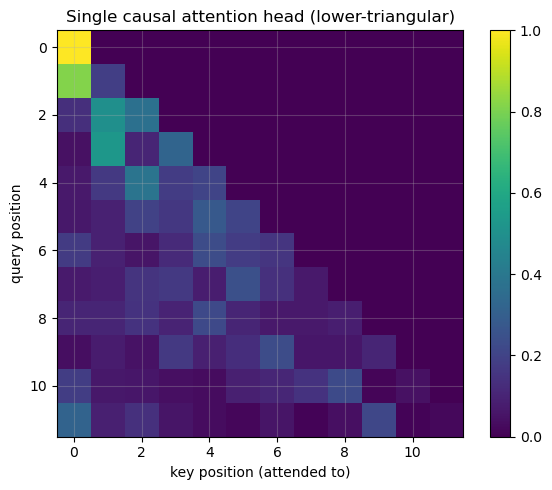

In [3]:
# One causal head, drawn from the Part-2 helpers.
T, d_head = 12, 8
qkv_key = jax.random.split(jax.random.PRNGKey(2), 3)
q1 = jax.random.normal(qkv_key[0], (T, d_head))
k1 = jax.random.normal(qkv_key[1], (T, d_head))
v1 = jax.random.normal(qkv_key[2], (T, d_head))
_, attn1 = scaled_dot_product_attention(q1, k1, v1, causal_mask(T))
print("attention row sums (should be 1):", np.array(attn1.sum(axis=-1)).round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.array(attn1), cmap="viridis", vmin=0, vmax=1)
ax.set_title("Single causal attention head (lower-triangular)")
ax.set_xlabel("key position (attended to)"); ax.set_ylabel("query position")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">2. A tiny Flax module to learn the init / apply flow</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Before building attention, let us see the Flax workflow on the smallest possible example. The module below has one <code>nn.Dense</code> layer followed by a <code>gelu</code>. We instantiate it, call <code>init</code> with a PRNG key to materialise the weights, inspect the parameter pytree, and finally call <code>apply</code> to run the forward pass. Notice that the weights live outside the module, in the dictionary returned by <code>init</code>.
</p>
</p>

In [4]:
# GIVEN: the Flax init/apply pattern on a one-layer module.
class TinyMLP(nn.Module):
    hidden: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.hidden, name="fc")(x)
        return nn.gelu(x)

tiny = TinyMLP(hidden=8)
demo_x = jnp.ones((2, 4))                       # batch of 2, feature width 4
tiny_params = tiny.init(jax.random.PRNGKey(0), demo_x)   # deterministic on CPU

print("parameter pytree (name -> shape):")
shapes = jax.tree_util.tree_map(lambda a: a.shape, tiny_params)
print(shapes)
y = tiny.apply(tiny_params, demo_x)             # run the forward pass with those params
print("apply output shape:", y.shape)
print("kernel shape:", tiny_params["params"]["fc"]["kernel"].shape,
      "| bias shape:", tiny_params["params"]["fc"]["bias"].shape)

parameter pytree (name -> shape):
{'params': {'fc': {'bias': (8,), 'kernel': (4, 8)}}}
apply output shape: (2, 8)
kernel shape: (4, 8) | bias shape: (8,)


<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">Learning note &mdash; Why one shared qkv projection</h4>
<p style="line-height:180%; font-size:medium;">
Rather than three separate linear layers for queries, keys, and values, the module below uses a single <code>nn.Dense(3*C)</code> and then splits the result into three equal pieces along the last axis. This is mathematically identical to three independent projections but lets the compiler fuse the work into one matrix multiply, which is why production implementations always write it this way. After the split, each of Q, K, V is reshaped so the head axis sits before the time axis, giving shape <code>(B, n_head, T, d_head)</code> on which attention runs independently per head.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">3. Implement causal multi-head self-attention as a Flax module</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete the module <code>CausalSelfAttention</code>. It has fields <code>n_head</code>, <code>n_embd</code>, and <code>dropout</code>, and a <code>@nn.compact __call__</code>. Build the shared qkv projection with <code>nn.Dense(3 * C, use_bias=False, name="qkv")</code>, split it into <code>q, k, v</code>, reshape each into heads, compute scaled dot-product scores, apply the causal mask, take the softmax, recombine the heads, and project back with <code>nn.Dense(C, name="proj")</code>. Keep the layer names <code>"qkv"</code> and <code>"proj"</code> exactly, because the judge and the charts read those keys.
</p>
</p>

In [5]:
class CausalSelfAttention(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        B, T, C = x.shape
        d_head = C // self.n_head

        # One shared projection to queries, keys and values, then split into 3
        qkv = nn.Dense(3 * C, use_bias=False, name="qkv")(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        # Reshape each of q, k, v to (B, n_head, T, d_head)
        def split_heads(t):
            return t.reshape(B, T, self.n_head, d_head).transpose(0, 2, 1, 3)
            
        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Scaled dot-product scores, causal mask, softmax
        scores = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(d_head)
        mask = jnp.tril(jnp.ones((T, T), dtype=bool))
        scores = jnp.where(mask, scores, -1e9)
        attn = jax.nn.softmax(scores, axis=-1)
        attn = nn.Dropout(self.dropout)(attn, deterministic=deterministic)

        # Weighted sum of values, recombine heads, then the output projection
        out = attn @ v
        out = out.transpose(0, 2, 1, 3).reshape(B, T, C)
        out = nn.Dense(C, name="proj")(out)
        out = nn.Dropout(self.dropout)(out, deterministic=deterministic)
        
        return out

In [6]:
# Self-check: shapes and the qkv kernel.
_x = jax.random.normal(jax.random.PRNGKey(3), (4, 16, 32))
mha_check = CausalSelfAttention(n_head=4, n_embd=32)
mha_check_p = mha_check.init(jax.random.PRNGKey(0), _x)
_out = mha_check.apply(mha_check_p, _x)
assert _out.shape == (4, 16, 32), _out.shape
assert mha_check_p["params"]["qkv"]["kernel"].shape == (32, 96), \
    mha_check_p["params"]["qkv"]["kernel"].shape
print("OK: output shape", _out.shape, "| qkv kernel", mha_check_p["params"]["qkv"]["kernel"].shape)
print("heads:", 4, "-> d_head:", 32 // 4)

OK: output shape (4, 16, 32) | qkv kernel (32, 96)
heads: 4 -> d_head: 8


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">4. What does each head look at? Per-head attention maps</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Each head induces its own attention pattern. Below we embed a fixed Shakespeare snippet, push it through the qkv kernel of the initialised module, and draw the causal attention matrix for every head. Because the weights are random at initialisation the patterns are not yet meaningful, but the plot shows the structure: a lower-triangular matrix per head, each free to weight the past differently. After training, these maps become interpretable specialists.
</p>
</p>
<div style="text-align:center;">
    <img src="images/tapsi5.jpg" style="width:100%;">
</div>

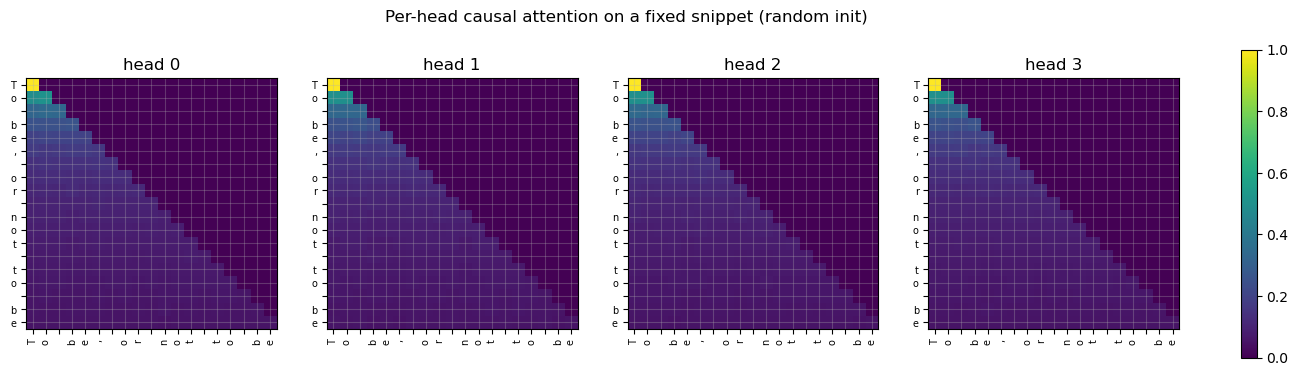

In [7]:
# Per-head attention heatmaps from the qkv kernel on a fixed snippet.
snippet = "To be, or not to be"
ids = jnp.asarray(encode(snippet))[None, :]              # (1, T)
T = ids.shape[1]
n_head, n_embd = 4, 32

embed = nn.Embed(vocab_size, n_embd, name="emb")
ekey, akey = jax.random.split(jax.random.PRNGKey(0))
emb_p = embed.init(ekey, ids)
xe = embed.apply(emb_p, ids)                             # (1, T, n_embd)

mha_vis = CausalSelfAttention(n_head=n_head, n_embd=n_embd)
vis_p = mha_vis.init(akey, xe)
W = vis_p["params"]["qkv"]["kernel"]                     # (n_embd, 3*n_embd)

d_head = n_embd // n_head
qkv = xe @ W
q, k, _ = jnp.split(qkv, 3, axis=-1)
def _sh(t): return t.reshape(1, T, n_head, d_head).transpose(0, 2, 1, 3)
q, k = _sh(q), _sh(k)
scores = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(d_head)
mask = jnp.tril(jnp.ones((T, T), dtype=bool))
scores = jnp.where(mask, scores, -1e9)
attn = jax.nn.softmax(scores, axis=-1)                   # (1, n_head, T, T)

labels = list(snippet)
fig, axes = plt.subplots(1, n_head, figsize=(16, 4))
for h in range(n_head):
    ax = axes[h]
    im = ax.imshow(np.array(attn[0, h]), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"head {h}")
    ax.set_xticks(range(T)); ax.set_xticklabels(labels, fontsize=7, rotation=90)
    ax.set_yticks(range(T)); ax.set_yticklabels(labels, fontsize=7)
fig.suptitle("Per-head causal attention on a fixed snippet (random init)")
fig.colorbar(im, ax=axes, fraction=0.02); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">5. GELU versus ReLU and tanh</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
The block's MLP uses GELU. The chart contrasts the three classic activations over the same input range so the difference is concrete: ReLU hard-zeros negatives, tanh saturates symmetrically, and GELU is a smooth gate that lets a little negative signal through near the origin.
</p>
</p>

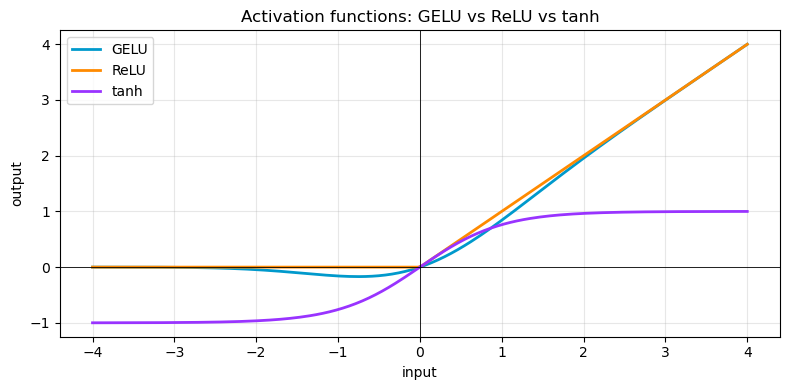

In [8]:
xs = jnp.linspace(-4.0, 4.0, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.array(xs), np.array(nn.gelu(xs)), label="GELU", color="#0099cc", linewidth=2)
ax.plot(np.array(xs), np.array(jax.nn.relu(xs)), label="ReLU", color="#ff8a00", linewidth=2)
ax.plot(np.array(xs), np.array(jnp.tanh(xs)), label="tanh", color="#9933ff", linewidth=2)
ax.axhline(0, color="black", linewidth=0.6); ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Activation functions: GELU vs ReLU vs tanh")
ax.set_xlabel("input"); ax.set_ylabel("output"); ax.legend()
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">6. Implement LayerNorm by hand</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete <code>manual_layernorm</code>. Compute the mean and variance over the <b>last</b> axis with <code>keepdims=True</code>, standardise <code>x</code>, then scale by <code>gamma</code> and shift by <code>beta</code>. With <code>gamma=1</code> and <code>beta=0</code> your result must match Flax's <code>nn.LayerNorm</code>, which the self-check verifies.
</p>
</p>

In [9]:
def manual_layernorm(x, gamma, beta, eps=1e-5):
    # Normalize x over the last axis, then apply the learned scale and shift
    mu = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    
    return gamma * (x - mu) / jnp.sqrt(var + eps) + beta

OK: manual_layernorm matches flax nn.LayerNorm within 1e-4


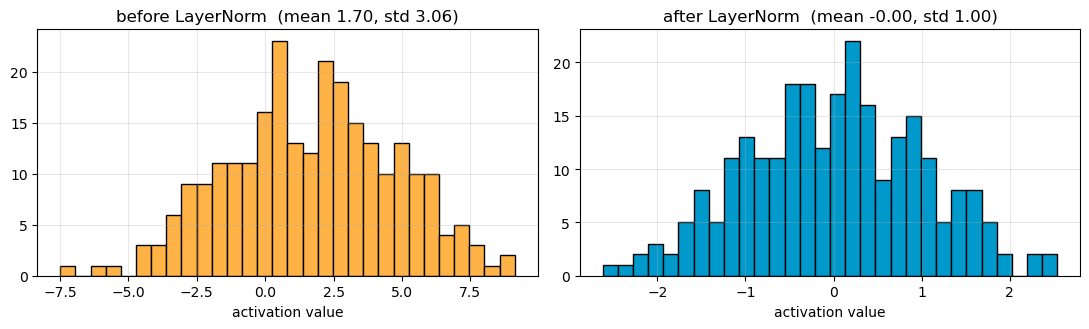

In [10]:
# Self-check: must match flax nn.LayerNorm (gamma=1, beta=0), and a before/after histogram.
_ln_x = jax.random.normal(jax.random.PRNGKey(5), (8, 32)) * 3.0 + 2.0   # shifted & scaled
flax_ln = nn.LayerNorm()
ln_p = flax_ln.init(jax.random.PRNGKey(0), _ln_x)
ref = flax_ln.apply(ln_p, _ln_x)
mine = manual_layernorm(_ln_x, gamma=1.0, beta=0.0)
assert jnp.allclose(mine, ref, atol=1e-4), float(jnp.max(jnp.abs(mine - ref)))
print("OK: manual_layernorm matches flax nn.LayerNorm within 1e-4")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(np.array(_ln_x).ravel(), bins=30, color="#ffb347", edgecolor="black")
ax[0].set_title(f"before LayerNorm  (mean {float(_ln_x.mean()):.2f}, std {float(_ln_x.std()):.2f})")
ax[1].hist(np.array(mine).ravel(), bins=30, color="#0099cc", edgecolor="black")
ax[1].set_title(f"after LayerNorm  (mean {float(mine.mean()):.2f}, std {float(mine.std()):.2f})")
for a in ax: a.set_xlabel("activation value")
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">7. Assemble the full pre-norm Transformer block</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete <code>TransformerBlock</code>. Use the pre-norm layout: first add the attention output of a LayerNorm-ed input back to <code>x</code>, then add the MLP output of a second LayerNorm-ed <code>x</code>. The MLP is <code>Dense(4 * n_embd)</code>, then <code>nn.gelu</code>, then <code>Dense(n_embd)</code>, with a dropout. Re-use the <code>CausalSelfAttention</code> module you wrote above. The output shape must equal the input shape.
</p>
</p>

In [11]:
class TransformerBlock(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        # Pre-norm attention sub-block with a residual connection
        attn_input = nn.LayerNorm()(x)
        x = x + CausalSelfAttention(
            n_head=self.n_head, 
            n_embd=self.n_embd, 
            dropout=self.dropout
        )(attn_input, deterministic=deterministic)

        # Pre-norm position-wise MLP sub-block with a residual connection
        h = nn.LayerNorm()(x)
        h = nn.Dense(4 * self.n_embd)(h)
        h = nn.gelu(h)
        h = nn.Dense(self.n_embd)(h)
        h = nn.Dropout(self.dropout)(h, deterministic=deterministic)
        
        return x + h

OK: block output shape (4, 16, 32) == input shape


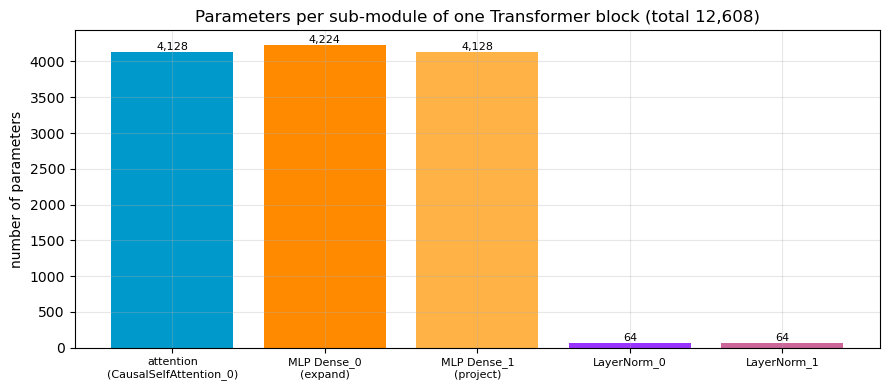

In [12]:
# Self-check: output shape equals input shape.
_bx = jax.random.normal(jax.random.PRNGKey(4), (4, 16, 32))
blk_check = TransformerBlock(n_head=4, n_embd=32)
bp = blk_check.init(jax.random.PRNGKey(0), _bx)
_bo = blk_check.apply(bp, _bx)
assert _bo.shape == _bx.shape == (4, 16, 32), (_bo.shape, _bx.shape)
print("OK: block output shape", _bo.shape, "== input shape")

# CHART: parameter counts per sub-module read straight from the param pytree.
def _count(tree):
    return int(sum(np.prod(a.shape) for a in jax.tree_util.tree_leaves(tree)))
prm = bp["params"]
groups = {
    "attention\n(CausalSelfAttention_0)": _count(prm["CausalSelfAttention_0"]),
    "MLP Dense_0\n(expand)": _count(prm["Dense_0"]),
    "MLP Dense_1\n(project)": _count(prm["Dense_1"]),
    "LayerNorm_0": _count(prm["LayerNorm_0"]),
    "LayerNorm_1": _count(prm["LayerNorm_1"]),
}
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(groups)), list(groups.values()),
       color=["#0099cc", "#ff8a00", "#ffb347", "#9933ff", "#cc6699"])
ax.set_xticks(range(len(groups))); ax.set_xticklabels(list(groups.keys()), fontsize=8)
ax.set_ylabel("number of parameters")
ax.set_title(f"Parameters per sub-module of one Transformer block (total {sum(groups.values()):,})")
for i, v in enumerate(groups.values()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#FF6A13">8. Bonus analysis: how the residual stream grows with depth</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
A useful diagnostic is how the magnitude of the activations evolves as identical blocks are stacked. Because every block adds to the residual stream, the norm tends to drift upward with depth, which is part of why pre-norm and LayerNorm matter. Below we pass a fixed input through a growing stack of freshly initialised blocks and plot the mean activation norm per position at each depth.
</p>
</p>

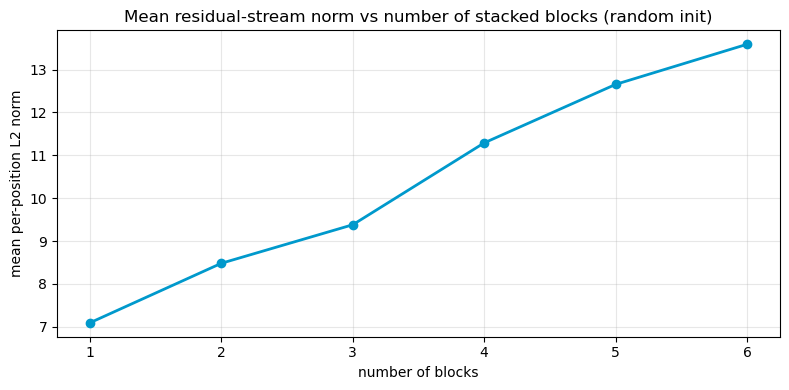

norms by depth: [7.095, 8.483, 9.382, 11.291, 12.654, 13.59]


In [13]:
depths = [1, 2, 3, 4, 5, 6]
x0 = jax.random.normal(jax.random.PRNGKey(8), (1, 16, 32))
norms = []
for d in depths:
    h = x0
    for i in range(d):
        b = TransformerBlock(n_head=4, n_embd=32)
        bpi = b.init(jax.random.PRNGKey(100 + i), h)
        h = b.apply(bpi, h)
    norms.append(float(jnp.mean(jnp.linalg.norm(h, axis=-1))))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, norms, "-o", color="#0099cc", linewidth=2)
ax.set_title("Mean residual-stream norm vs number of stacked blocks (random init)")
ax.set_xlabel("number of blocks"); ax.set_ylabel("mean per-position L2 norm")
plt.tight_layout(); plt.show()
print("norms by depth:", [round(v, 3) for v in norms])